In [27]:
%load_ext autoreload
%autoreload 2
from aml_detection.dataset_loader import load_dataset, summarise

df = load_dataset(nrows=200_000)
summarise(df)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-08-16 00:30:09.278 | INFO     | aml_detection.dataset_loader:load_raw:69 - Reading /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/data/raw/HI-Small_Trans.csv (first 200,000 rows)
2026-08-16 00:30:09.513 | SUCCESS  | aml_detection.dataset_loader:load_raw:84 - Read 200,000 rows x 11 columns
2026-08-16 00:30:09.513 | INFO     | aml_detection.dataset_loader:clean:192 - Cleaning transactions
2026-08-16 00:30:09.852 | SUCCESS  | aml_detection.dataset_loader:clean:206 - Cleaned 200,000 rows | laundering 0.0125% | self-loops 73.6%


rows                                 200000
unique_accounts                      161507
laundering_rate                    0.000125
laundering_count                         25
self_loop_share                    0.736285
cross_currency_share               0.003515
start                   2022-09-01 00:00:00
end                     2022-09-04 15:48:00
days_covered                              3
dtype: object

In [4]:
import pandas as pd
from aml_detection.config import RAW_DATA_DIR

acc = pd.read_csv(RAW_DATA_DIR / "HI-Small_accounts.csv")
print(acc.shape)
print(acc.dtypes)
acc.head()

(518581, 5)
Bank Name         object
Bank ID            int64
Account Number    object
Entity ID         object
Entity Name       object
dtype: object


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [6]:
acc = acc.assign(
    account_key=lambda d: d["Bank ID"].astype(str) + "_" + d["Account Number"]
)

# CRITICAL: check uniqueness before merging, or you silently duplicate rows
print("rows:", len(acc), "| unique keys:", acc["account_key"].nunique())

acc = acc.assign(
    entity_type=lambda d: d["Entity Name"].str.split("#").str[0].str.strip(),
    bank_country=lambda d: d["Bank Name"].str.split("Bank").str[0].str.strip(),
)
print(acc.entity_type.value_counts())
print(acc.bank_country.value_counts().head(10))
merged = df.merge(acc, left_on="src_account", right_on="account_key", how="left")

for col in ["entity_type", "bank_country"]:
    r = merged.groupby(col)["is_laundering"].mean().sort_values(ascending=False)
    print(f"\n{col} | overall {merged.is_laundering.mean():.4f}")
    print(r.head(8))

# leakage probe on the numeric suffix
merged["entity_num"] = merged["Entity Name"].str.extract(r"#(\d+)").astype(float)
print("\nsuffix corr:", merged["entity_num"].corr(merged["is_laundering"]).round(4))

rows: 518581 | unique keys: 518581
entity_type
Partnership            189683
Corporation            172351
Sole Proprietorship    149048
Country                  6692
Individual                740
Direct                     67
Name: count, dtype: int64
bank_country
National       36077
Savings        35234
First          35227
Germany        32733
               28250
Switzerland    24949
China          23489
France         21416
India          19359
Israel         19248
Name: count, dtype: int64

entity_type | overall 0.0001
entity_type
Sole Proprietorship    0.000327
Partnership            0.000043
Corporation            0.000000
Country                0.000000
Direct                 0.000000
Individual             0.000000
Name: is_laundering, dtype: float64

bank_country | overall 0.0001
bank_country
Oasis Thrift          0.002008
                      0.000972
National              0.000048
Oasis Bancorp         0.000000
Oasis Savings         0.000000
Oasis Federal         0.00000

In [7]:
import pandas as pd
from aml_detection.config import RAW_DATA_DIR
from aml_detection.dataset_loader import load_dataset

# ---- 1. Load the FULL file (no nrows cap) -------------------------------
# The first 200K rows are not representative; laundering is spread across
# the whole 10-day span.
df = load_dataset()

print(f"rows              : {len(df):,}")
print(f"laundering count  : {df.is_laundering.sum():,}")
print(f"laundering rate   : {df.is_laundering.mean():.5%}")
print(f"span              : {df.timestamp.min()} -> {df.timestamp.max()}")

# where do the positives actually sit in the file?
print("\npositives by day:")
print(df.groupby(df.timestamp.dt.date)["is_laundering"].agg(["sum", "mean"]))


# ---- 2. Accounts file, parsed properly ----------------------------------
acc = pd.read_csv(RAW_DATA_DIR / "HI-Small_accounts.csv")

VALID_ENTITY = ["Corporation", "Partnership", "Sole Proprietorship", "Individual"]

acc = acc.assign(
    account_key=lambda d: d["Bank ID"].astype(str) + "_" + d["Account Number"],
    entity_type=lambda d: d["Entity Name"]
        .str.split("#").str[0].str.strip()
        .where(lambda s: s.isin(VALID_ENTITY), "Other"),
    # "Portugal Bank #4507" -> Portugal ; "National Bank of Harrisburg" -> Named/US
    bank_country=lambda d: d["Bank Name"]
        .str.extract(r"^(.+?)\s+Bank\s+#\d+$")[0]
        .fillna("Named/US"),
)

assert acc.account_key.is_unique, "duplicate account keys -- merge would fan out rows"

print("\nentity_type:\n", acc.entity_type.value_counts())
print("\nbank_country (top 10):\n", acc.bank_country.value_counts().head(10))


# ---- 3. Leakage check on the full data ----------------------------------
merged = df.merge(
    acc[["account_key", "entity_type", "bank_country", "Entity Name"]],
    left_on="src_account", right_on="account_key", how="left",
)

print(f"\nunmatched accounts: {merged.account_key.isna().mean():.2%}")

overall = merged.is_laundering.mean()
for col in ["entity_type", "bank_country"]:
    rates = merged.groupby(col, observed=True)["is_laundering"].agg(["mean", "size"])
    rates = rates[rates["size"] >= 500].sort_values("mean", ascending=False)
    print(f"\n{col} | overall {overall:.5%}")
    print((rates.assign(lift=lambda d: d["mean"] / overall)).head(8))

# generation-artifact probe: does the entity number predict the label?
suffix = merged["Entity Name"].str.extract(r"#(\d+)")[0].astype(float)
print(f"\nentity suffix corr with label: {suffix.corr(merged.is_laundering):.4f}")
print("(near zero = no leakage, safe to ignore the suffix)")


2026-08-15 10:48:15.804 | INFO     | aml_detection.dataset_loader:load_raw:69 - Reading /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/data/raw/HI-Small_Trans.csv
2026-08-15 10:48:18.600 | SUCCESS  | aml_detection.dataset_loader:load_raw:84 - Read 5,078,345 rows x 11 columns
2026-08-15 10:48:18.600 | INFO     | aml_detection.dataset_loader:clean:149 - Cleaning transactions
2026-08-15 10:48:22.387 | SUCCESS  | aml_detection.dataset_loader:clean:161 - Cleaned 5,078,345 rows | laundering 0.1019% | self-loops 11.6%
rows              : 5,078,345
laundering count  : 5,177
laundering rate   : 0.10194%
span              : 2022-09-01 00:00:00 -> 2022-09-18 16:18:00

positives by day:
            sum      mean
timestamp                
2022-09-01  322  0.000289
2022-09-02  408  0.000541
2022-09-03  391  0.001885
2022-09-04  407  0.001962
2022-09-05  471  0.000976
2022-09-06  531  0.001101
2022-09-07  497  0.001030
2022-09-08  539  0.001116
2022-09-09  514  0.000785
20

In [8]:
per_day = df.groupby(df.timestamp.dt.date).agg(
    rows=("is_laundering", "size"),
    positives=("is_laundering", "sum"),
    rate=("is_laundering", "mean"),
)
print(per_day.to_string())

               rows  positives      rate
timestamp                               
2022-09-01  1114921        322  0.000289
2022-09-02   754449        408  0.000541
2022-09-03   207382        391  0.001885
2022-09-04   207430        407  0.001962
2022-09-05   482650        471  0.000976
2022-09-06   482089        531  0.001101
2022-09-07   482751        497  0.001030
2022-09-08   482773        539  0.001116
2022-09-09   654467        514  0.000785
2022-09-10   208325        442  0.002122
2022-09-11      396        232  0.585859
2022-09-12      281        170  0.604982
2022-09-13      184        106  0.576087
2022-09-14      121         70  0.578512
2022-09-15       46         28  0.608696
2022-09-16       46         26  0.565217
2022-09-17       23         15  0.652174
2022-09-18       11          8  0.727273


In [9]:
df=load_dataset()
print(df.timestamp.max())
print(f"{df.is_laundering.mean():.4%}")
print(df.is_burn_in.mean())

2026-08-15 11:06:01.054 | INFO     | aml_detection.dataset_loader:load_raw:69 - Reading /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/data/raw/HI-Small_Trans.csv
2026-08-15 11:06:03.833 | SUCCESS  | aml_detection.dataset_loader:load_raw:84 - Read 5,078,345 rows x 11 columns
2026-08-15 11:06:03.834 | INFO     | aml_detection.dataset_loader:clean:192 - Cleaning transactions
2026-08-15 11:06:04.414 | INFO     | aml_detection.dataset_loader:_drop_simulation_tail:170 - Dropped 1,108 tail rows on/after 2022-09-11 (0.022% of file)
2026-08-15 11:06:07.975 | SUCCESS  | aml_detection.dataset_loader:clean:206 - Cleaned 5,077,237 rows | laundering 0.0891% | self-loops 11.6%
2022-09-10 23:59:00
0.0891%
0.368186476227129


In [10]:
 print(df.groupby("is_burn_in")["is_laundering"].agg(["size", "sum", "mean"]))


               size   sum      mean
is_burn_in                         
False       3207867  3792  0.001182
True        1869370   730  0.000391


In [11]:
acc = pd.read_csv(RAW_DATA_DIR / "HI-Small_accounts.csv")

In [12]:
print(acc.head())

                     Bank Name  Bank ID  ...  Entity ID                 Entity Name
0          Portugal Bank #4507   331579  ...  80062E240  Sole Proprietorship #50438
1              Canada Bank #27      210  ...  800C998A0          Corporation #33520
2                  UK Bank #33    21884  ...  800C47F50          Partnership #35397
3           Germany Bank #4815    32742  ...  80096F0B0          Corporation #48813
4  National Bank of Harrisburg   127390  ...  800FB8760            Corporation #889

[5 rows x 5 columns]


In [13]:
acc['Bank Name'].value_counts()


Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
                               ... 
Belgium Bank #1913                1
Mexico Bank #222                  1
Austria Bank #3824                1
Japan Bank #640                   1
UK Bank #483                      1
Name: count, Length: 20053, dtype: int64

AttributeError: module 'os' has no attribute 'pwd'

In [21]:
import pandas as pd
from aml_detection.config import INTERIM_DATA_DIR

df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")
df.head(20)

,timestamp,src_bank,src_account,dst_bank,dst_account,amount_received,currency_received,amount_paid,currency_paid,payment_format,is_laundering,is_self_loop,is_cross_currency,amount_delta,is_burn_in,src_entity_type,src_bank_country,dst_entity_type,dst_bank_country
0,2022-09-01,32282,32282_801B64CE0,32282,32282_801B64CE0,29294.03,US Dollar,29294.03,US Dollar,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Named,Sole Proprietorship,Named
1,2022-09-01,212818,212818_804B1DF50,212818,212818_804B1DF50,538528.53,Rupee,538528.53,Rupee,Reinvestment,0,True,False,0.0,True,Partnership,India,Partnership,India
2,2022-09-01,16927,16927_8062913A0,28,28_806291440,96718657.00,Ruble,96718657.00,Ruble,ACH,0,False,False,0.0,True,Partnership,Russia,Partnership,Australia
3,2022-09-01,12561,12561_802CF1BB0,18428,18428_8095524B0,2122.85,Euro,2122.85,Euro,Credit Card,0,False,False,0.0,True,Sole Proprietorship,Spain,Partnership,Italy
4,2022-09-01,131086,131086_80CB3F220,131086,131086_80CB3F220,20289185.18,Mexican Peso,20289185.18,Mexican Peso,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Mexico,Sole Proprietorship,Mexico
5,2022-09-01,1068,1068_802AC9790,17425,17425_80EC2E740,3174.84,US Dollar,3174.84,US Dollar,Cheque,0,False,False,0.0,True,Corporation,Named,Sole Proprietorship,Named
6,2022-09-01,13264,13264_803D0EB90,227171,227171_80EC2DDC0,3198.62,US Dollar,3198.62,US Dollar,ACH,0,False,False,0.0,True,Partnership,Named,Sole Proprietorship,Named
7,2022-09-01,8354,8354_807350F90,8354,8354_807350F90,17.71,US Dollar,17.71,US Dollar,Reinvestment,0,True,False,0.0,True,Partnership,Named,Partnership,Named
8,2022-09-01,1132,1132_80BE5E680,1132,1132_80BE5E680,1057246.47,Mexican Peso,1057246.47,Mexican Peso,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Mexico,Sole Proprietorship,Mexico
9,2022-09-01,39900,39900_803D91A80,210261,210261_803D92040,0.03,Yen,0.03,Yen,Cheque,0,False,False,0.0,True,Partnership,Japan,Sole Proprietorship,Japan


### EDA 


In [22]:
import pandas as pd
from aml_detection.config import INTERIM_DATA_DIR

df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")

# temporal split - EDA on train only
SPLIT = df.timestamp.quantile(0.70)
train = df[df.timestamp <= SPLIT]
test  = df[df.timestamp >  SPLIT]      # do not touch until final evaluation

print(f"train {len(train):,} rows, {train.is_laundering.sum():,} positives")
print(f"test  {len(test):,} rows, {test.is_laundering.sum():,} positives")
print(f"split at {SPLIT}")

train 3,554,066 rows, 2,856 positives
test  1,523,171 rows, 1,666 positives
split at 2022-09-07 14:52:12


In [23]:
# 1. are the derived columns actually informative?
print("cross_currency rate:", train.is_cross_currency.mean())
print("nonzero amount_delta:", (train.amount_delta != 0).mean())

# 2. is is_self_loop just Reinvestment by another name?
print(train.groupby("payment_format", observed=True)
        .agg(self_loop=("is_self_loop", "mean"),
             n=("is_self_loop", "size"),
             laundering=("is_laundering", "mean")))

cross_currency rate: 0.013467673363409684
nonzero amount_delta: 0.013464296948903031
                self_loop        n  laundering
payment_format                                
ACH              0.118319   399953    0.005953
Bitcoin          0.216232   102085    0.000353
Cash             0.002952   327864    0.000226
Cheque           0.003266  1243542    0.000182
Credit Card      0.003155   883291    0.000157
Reinvestment     1.000000   481056    0.000000
Wire             0.004584   116275    0.000000


In [24]:
print(train.groupby("is_cross_currency").is_laundering.agg(["mean", "size"]))

                       mean     size
is_cross_currency                   
False              0.000815  3506201
True               0.000000    47865


In [25]:
print(train.groupby("payment_format", observed=True)
        .is_laundering.agg(["sum", "size", "mean"])
        .sort_values("sum", ascending=False))

                 sum     size      mean
payment_format                         
ACH             2381   399953  0.005953
Cheque           226  1243542  0.000182
Credit Card      139   883291  0.000157
Cash              74   327864  0.000226
Bitcoin           36   102085  0.000353
Reinvestment       0   481056  0.000000
Wire               0   116275  0.000000


In [26]:
print(train.groupby("payment_format", observed=True)
        .agg(median_amt=("amount_paid", "median"),
             p95_amt=("amount_paid", lambda s: s.quantile(0.95)),
             n_src=("src_account", "nunique")))

                median_amt       p95_amt   n_src
payment_format                                  
ACH             2056.51000  1.030495e+06  144928
Bitcoin            0.07343  1.951638e+01   13209
Cash            1834.07000  1.830117e+06   62790
Cheque          2004.33000  8.932689e+05  171438
Credit Card     1117.78000  1.040140e+05  126348
Reinvestment    1724.88000  1.978652e+06  354249
Wire            1061.99000  1.431801e+06   30504


2026-08-16 00:39:48.544 | INFO     | aml_detection.eda:target_balance:56 - 2,856 positives in 3,554,066 rows (0.0804%). 1 in 1,244.
2026-08-16 00:39:48.545 | WARNING  | aml_detection.eda:target_balance:61 - Severe imbalance: ROC-AUC will look flattering and mean little. Report PR-AUC and recall at a fixed alert budget instead.


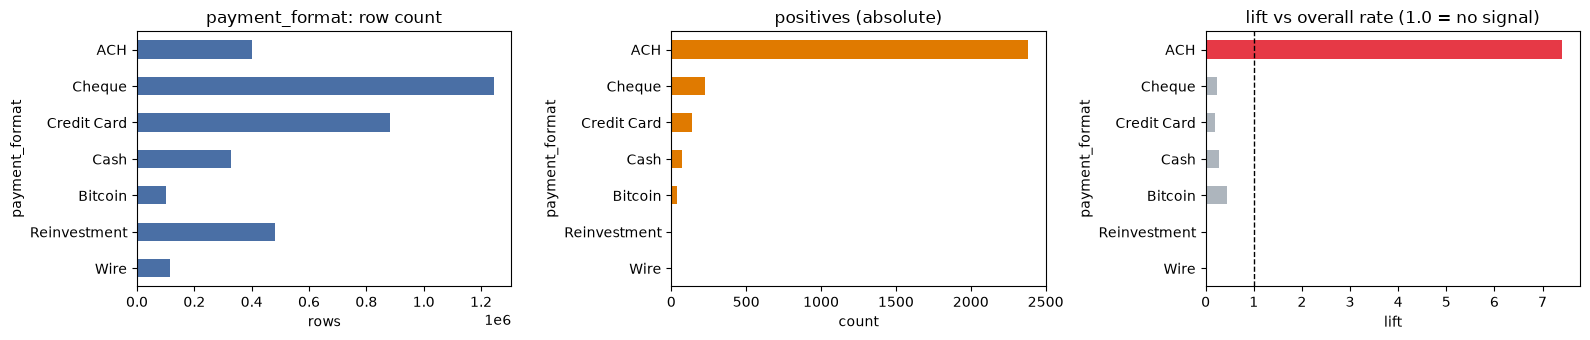

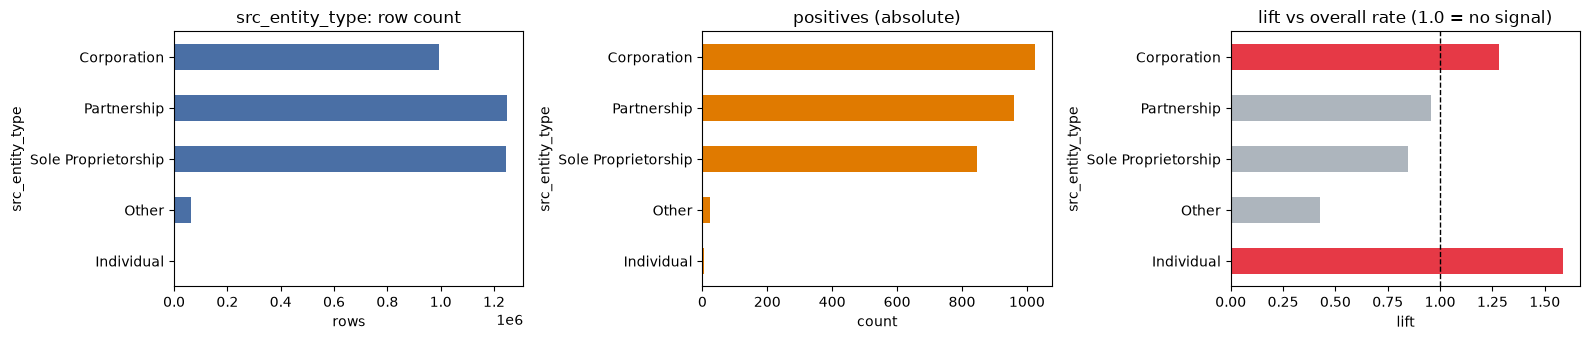

2026-08-16 00:39:49.912 | INFO     | aml_detection.eda:explore_categorical:101 - 5 categories below 500 rows excluded from plot


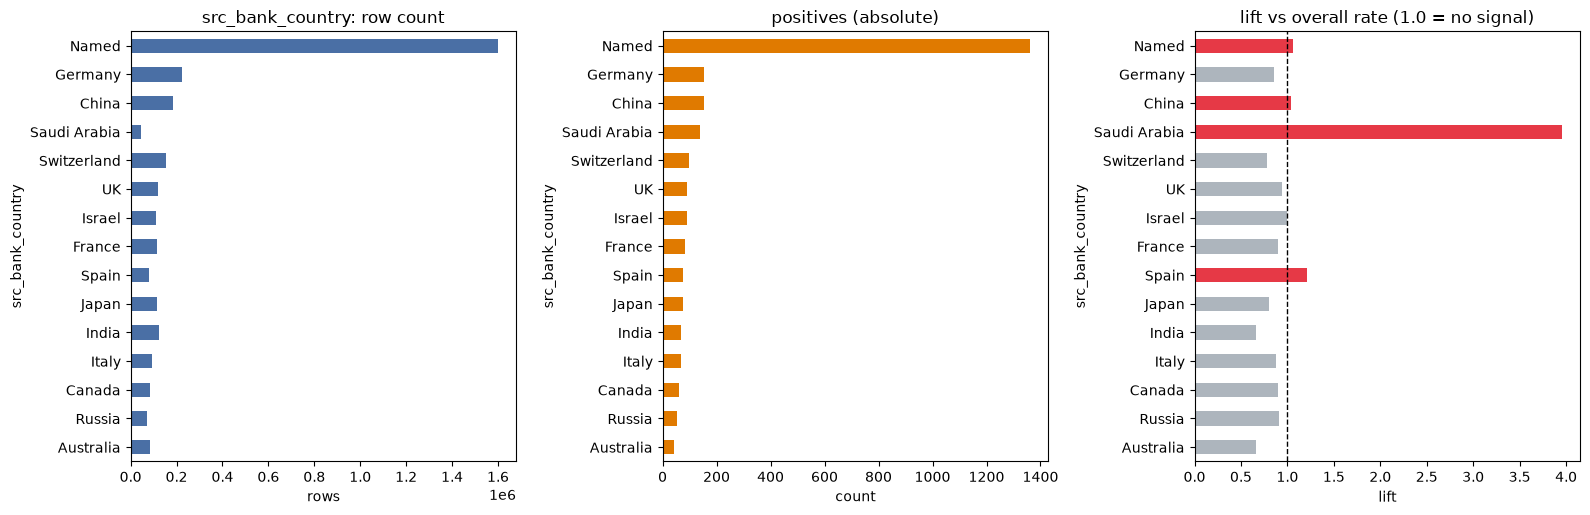

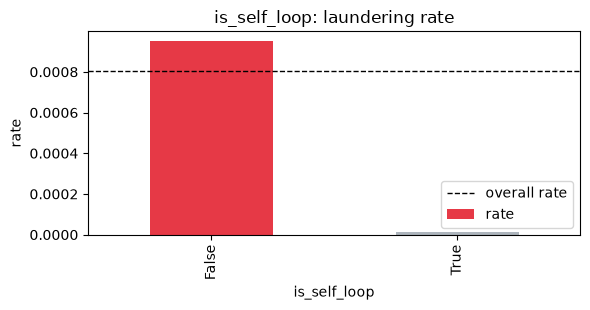

2026-08-16 00:39:50.459 | WARNING  | aml_detection.eda:explore_boolean:227 - is_cross_currency=[True] contains ZERO positives. Either the flag is useless, or those rows can be excluded from training entirely.


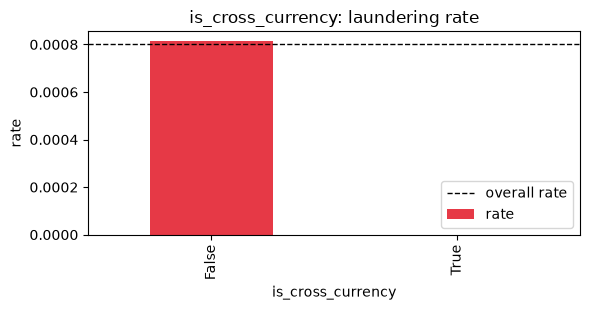

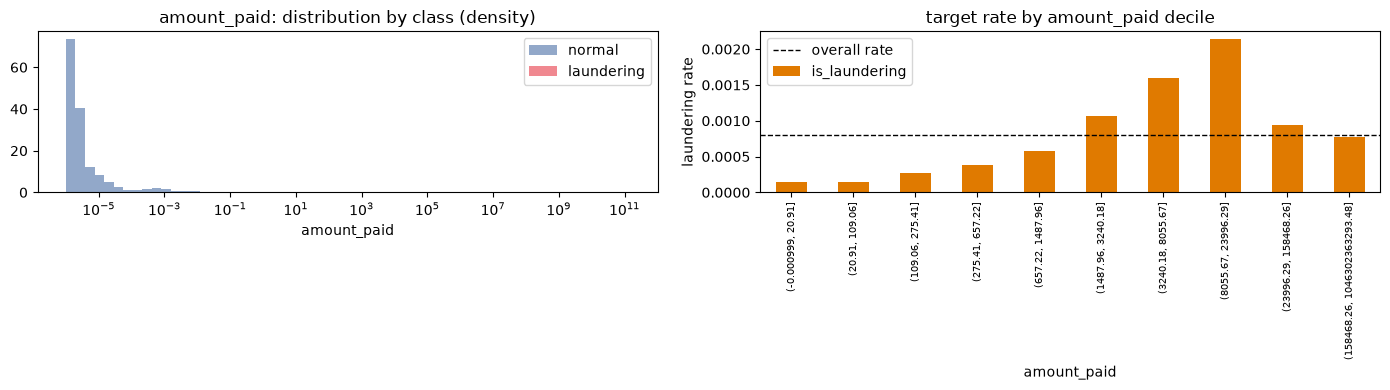

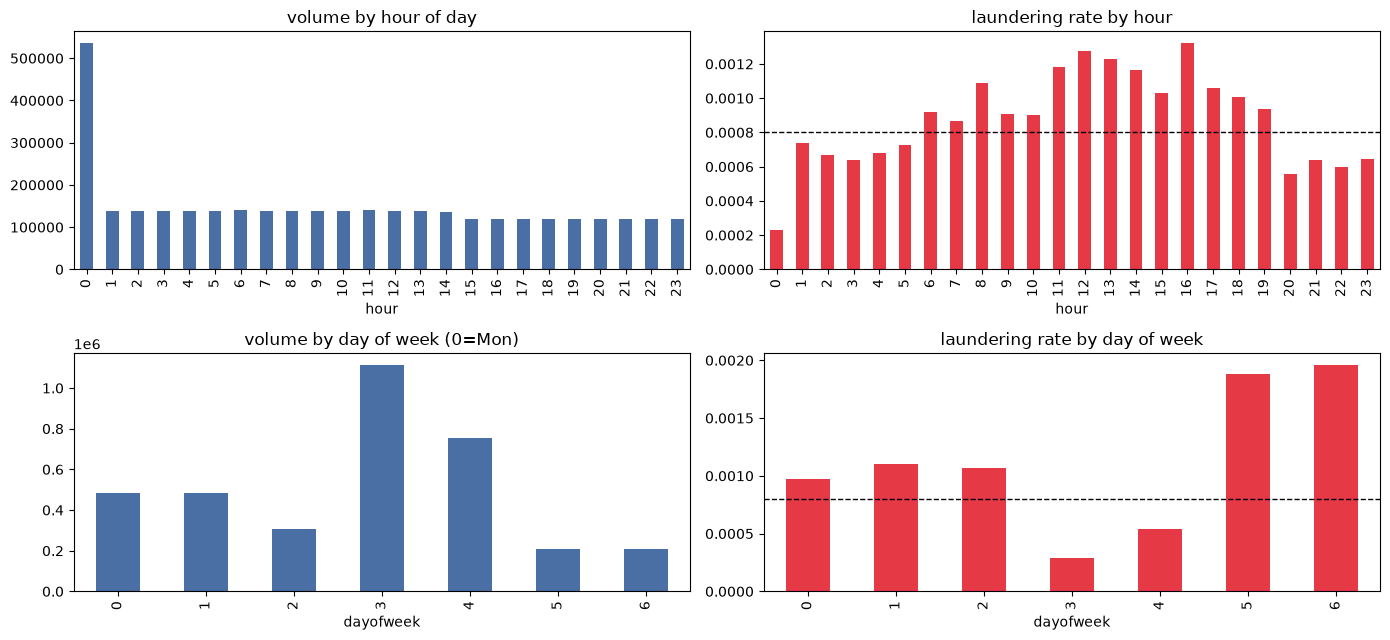

n  positives      rate
unit                                      
hour      0    536869        124  0.000231
          1    139213        103  0.000740
          2    138933         93  0.000669
          3    139198         89  0.000639
          4    138604         94  0.000678
          5    139418        101  0.000724
          6    140234        129  0.000920
          7    139185        121  0.000869
          8    137880        150  0.001088
          9    137915        125  0.000906
          10   138980        125  0.000899
          11   139564        165  0.001182
          12   138471        177  0.001278
          13   138659        170  0.001226
          14   136519        159  0.001165
          15   120461        124  0.001029
          16   119324        158  0.001324
          17   118700        126  0.001061
          18   119054        120  0.001008
          19   119460        112  0.000938
          20   119772         67  0.000559
          21   118887         76  0.000639
          22   118836         71  0.000597
          23   119930         77  0.000642
dayofweek 0    482650        471  0.000976
          1    482089        531  0.001101
          2    305145        326  0.001068
          3   1114921        322  0.000289
          4    754449        408  0.000541
          5    207382        391  0.001885
          6    207430        407  0.001962

In [30]:
import pandas as pd
from aml_detection.config import INTERIM_DATA_DIR
from aml_detection.eda import (
    overview, target_balance,
    explore_categorical, explore_numeric, explore_boolean, explore_temporal,
)

df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")
SPLIT = df.timestamp.quantile(0.70)
train = df[df.timestamp <= SPLIT]

# 1. shape of everything
overview(train)

# 2. what are we predicting
target_balance(train)

# 3. column by column
explore_categorical(train, "payment_format")
explore_categorical(train, "src_entity_type")
explore_categorical(train, "src_bank_country")

explore_boolean(train, "is_self_loop")
explore_boolean(train, "is_cross_currency")

explore_numeric(train, "amount_paid")

explore_temporal(train)

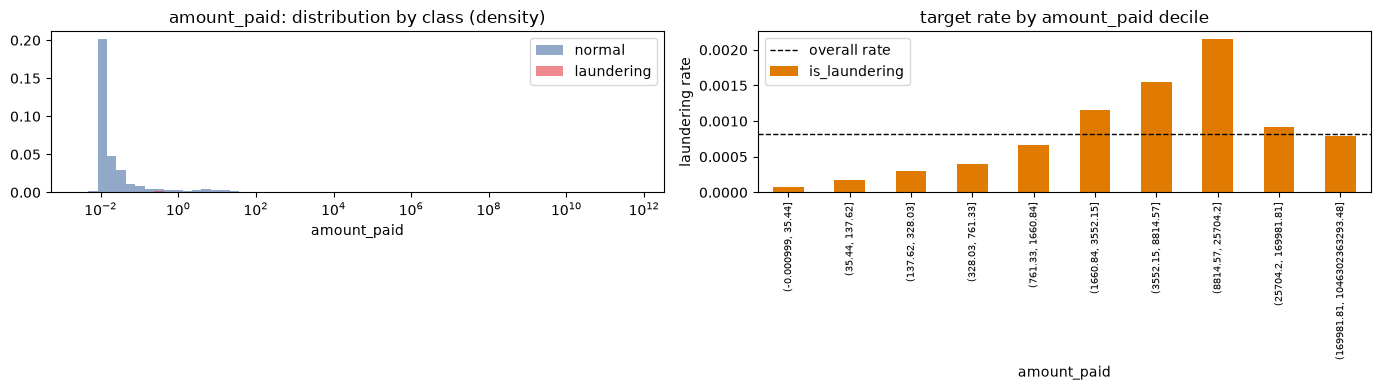

is_laundering,0,1
count,3.449161e+06,2.820000e+03
mean,5.173808e+06,6.488671e+07
std,9.860153e+08,2.069776e+09
min,1.000000e-06,3.300000e-01
25%,2.132200e+02,2.441677e+03
50%,1.657640e+03,7.650070e+03
75%,1.469586e+04,1.897067e+04
95%,7.659492e+05,7.941299e+05
99%,1.602506e+07,2.751157e+07
max,1.046302e+12,8.485314e+10


In [31]:
explore_numeric(train[train.payment_format != "Bitcoin"], "amount_paid")

In [32]:
# how different are the currencies in scale?
by_ccy = (
    train.groupby("currency_paid", observed=True)
    .agg(
        n=("amount_paid", "size"),
        median=("amount_paid", "median"),
        p95=("amount_paid", lambda s: s.quantile(0.95)),
        laundering=("is_laundering", "mean"),
        positives=("is_laundering", "sum"),
    )
    .sort_values("n", ascending=False)
)
print(by_ccy.to_string())

# does the laundering-vs-normal gap survive within a single currency?
usd = train[train.currency_paid == "US Dollar"]
print("\nUS Dollar only:")
print(usd.groupby("is_laundering").amount_paid.describe([.25,.5,.75,.95]).T.to_string())

                         n         median           p95  laundering  positives
currency_paid                                                                 
US Dollar          1325768     962.160000  2.241694e+05    0.000798       1058
Euro                818922     797.950000  1.827400e+05    0.000880        721
Swiss Franc         164817     843.380000  1.981664e+05    0.000686        113
Yuan                149563    6360.160000  1.444823e+06    0.000802        120
Shekel              134447    3316.830000  6.929900e+05    0.000491         66
Rupee               133220   69166.000000  2.117758e+07    0.000788        105
UK Pound            126036     732.385000  1.660002e+05    0.000666         84
Yen                 108672  101536.510000  2.751686e+07    0.000589         64
Ruble               108426   73114.945000  2.155322e+07    0.000775         84
Bitcoin             102067       0.073273  1.915418e+01    0.000353         36
Canadian Dollar      98008    1214.430000  2.676387e